# Spectral estimation Lab

## Imports

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import scipy.signal
import statsmodels.api as sm

## 1. Autoregressive process

### 1.1 Synthesis

1. Code a function that synthesizes an autoregressive (AR) process of length N, defined by its AR coefficients and the innovation variance $\sigma^2$

In [38]:
def synthetize_AR(N, ARCoefficients, sigma2=1):
    """
    Synthesizes an autoregressive (AR) process of length N,
    defined by its ARcoefficients and the innovation variance σ^2
    """
    ARCoefficients = np.array(ARCoefficients)
    p = len(ARCoefficients)
    signal = np.zeros(N)
    noise = np.random.normal(0, np.sqrt(sigma2), N)
    for n in range(p,N):
        signal[n] = np.dot(ARCoefficients, signal[n-p:n][::-1]) + noise[n]
    return signal

print(synthetize_AR(30, [0.5, -0.3], sigma2=1))

[ 0.          0.         -0.85806117  0.11372446  1.18240652  2.3517861
  1.74933012  0.29807436  1.00845682  1.06592222  0.59914455  1.28393471
 -0.09394727  0.03619869  0.76962409  0.5688643   0.29762353 -0.95713155
 -0.63453204  1.64989304  1.08813382 -0.76602156 -1.52945564  0.41606435
  1.14932489  0.43349608 -0.64324528 -1.06153523 -0.05525954  0.1036184 ]


### 1.2 Non-parametric estimation : periodogram

2. Code a function that computes and displays the periodogram of a given input signal, allowing to choose between the standard method and the Bartlett and Welsh methods.

In [76]:
def periodogram(signal, method='standard', bartlett_L=None, welch_S=None, welch_K=None):
    """
    Computes the periodogram of a given input signal, allowing to
    choose between the standard ('standard') method and the Bartlett ('bartlett') and Welch ('welch') methods
    """

    if method not in ["standard", "bartlett", "welch"]:
        raise ValueError("Invalid method. Choose 'standard', 'bartlett', or 'welch'.")

    if method == 'standard':
        def standard(nu):
            N = len(signal)
            return 1/N * abs(np.sum(signal * np.exp(-2j * np.pi * nu * np.arange(N))))**2
        return standard
    
    elif method == 'bartlett':
        def bartlett(nu):
            N = len(signal)
            L = bartlett_L if bartlett_L is not None else int(N / 4)
            M = int(N/L)
            S_B = 0
            for i in range(L):
                X_tilde = signal[i * M : (i + 1) * M]
                t = np.arange(1, M + 1)
                periodogram_i = (1 / M) * np.abs(np.sum(X_tilde * np.exp(-2j * np.pi * nu * t)))**2
                S_B += periodogram_i
                
            return S_B / L
        return bartlett
    
    elif method == 'welch':
        def welch(nu):
            N = len(signal)
            M = int(N / 4)
            K = int(M / 2) 
            S = int((N - M) / K) + 1
            v = np.hamming(M)
            
            P = (1 / M) * np.sum(np.abs(v)**2)
            
            S_W = 0
            for i in range(1, S + 1):
                start = (i - 1) * K
                X_tilde = signal[start : start + M]
                t = np.arange(1, M + 1)
                periodogram_i = (1 / (M * P)) * np.abs(np.sum(v * X_tilde * np.exp(-2j * np.pi * nu * t)))**2
                S_W += periodogram_i
                
            return S_W / S
            
        return welch

def show_periodogram(signal, resolution=1e-3, methods=['standard'], bartlett_L=None, welch_S=None, welch_K=None):
    """
    Displays the periodogram of the process using the chosen method(s).
    Choose between the standard ('standard') method and the Bartlett ('bartlett') and Welch ('welch') methods
    """
    nu_values = np.arange(0, 0.5, resolution)
    plt.figure(figsize=(10, 6))
    
    for method in methods:
        if method not in ["standard", "bartlett", "welch"]:
            raise ValueError(f"Invalid method '{method}'. Choose 'standard', 'bartlett', or 'welch'.")
        
        periodogram_func = periodogram(signal, method, bartlett_L=bartlett_L, welch_S=welch_S, welch_K=welch_K)
        periodogram_values = [periodogram_func(nu) for nu in nu_values]
        plt.plot(nu_values, periodogram_values, label=method.capitalize())
        
    plt.xlabel('Frequency')
    plt.ylabel('Power')
    plt.title('Periodogram Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

3. Display the periodograms obtained with the different methods (in dB), in the case of an AR process of order 1 whose parameters can be chosen by hand. We will superimpose in each case the periodogram with the known power spectral density (PSD) of the AR process. We will pay attention to the correct normalization of the different estimators.

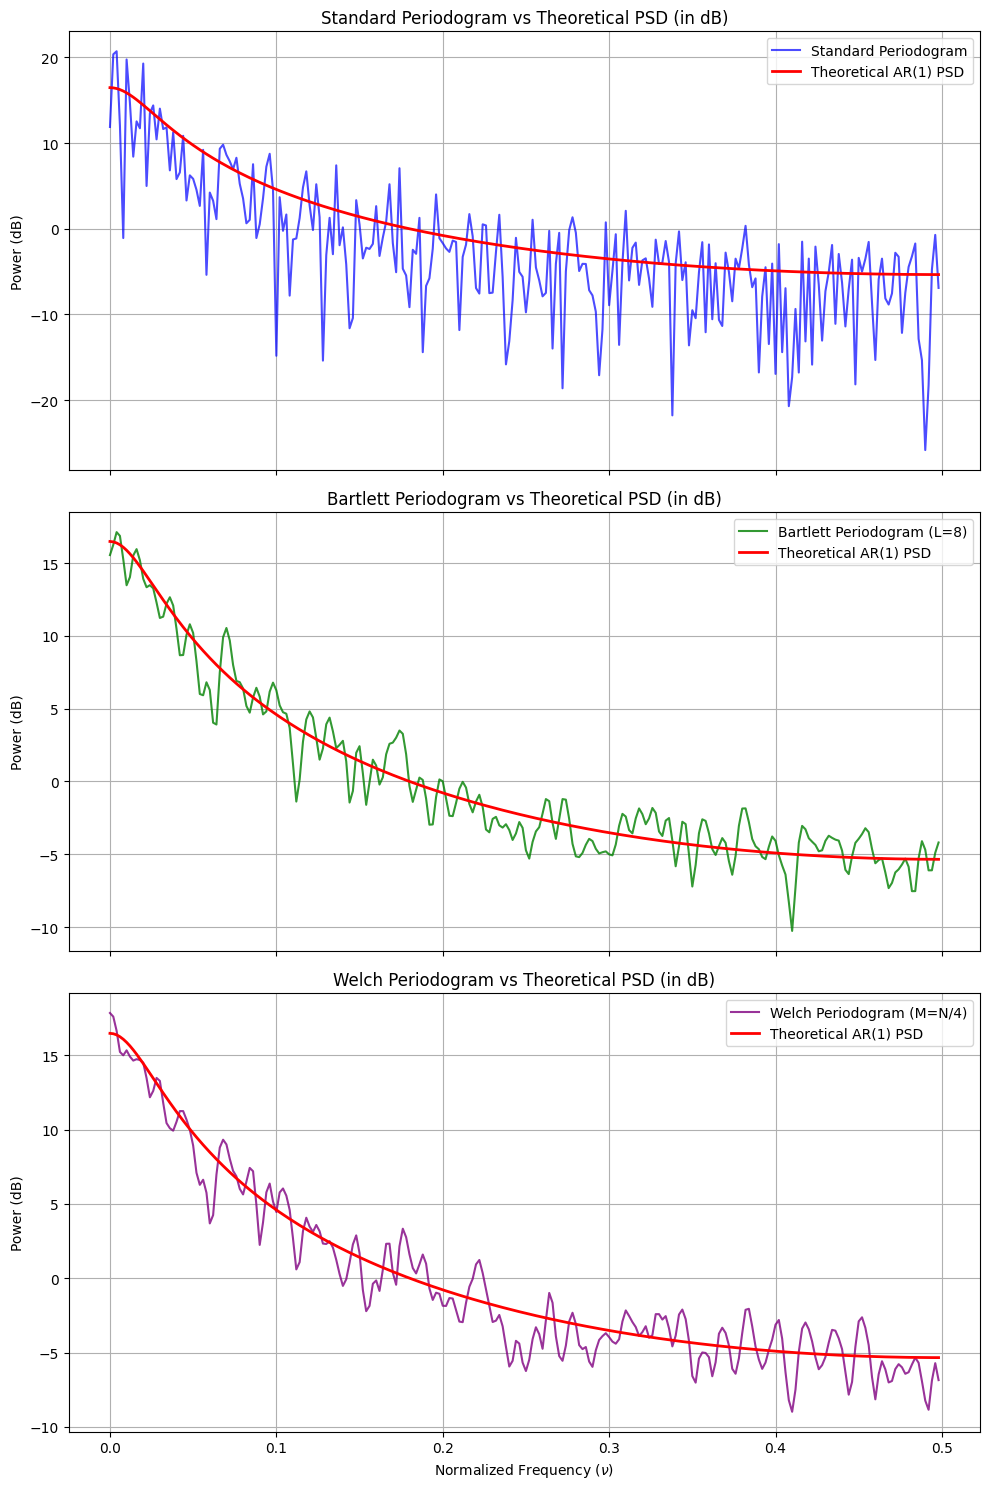

In [110]:
N = 1000
np.random.seed(42)

variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)

a = 0.85 

for t in range(1, N):
    signal[t] = a * signal[t-1] + noise[t]

nu_values = np.arange(0, 0.5, 0.002)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2

theoretical_psd_db = 10 * np.log10(theoretical_psd)

std_periodogram = periodogram(signal, 'standard')
bart_periodogram = periodogram(signal, 'bartlett', bartlett_L=8)
welch_periodogram = periodogram(signal, 'welch')

p_std = np.array([std_periodogram(nu) for nu in nu_values])
p_bar = np.array([bart_periodogram(nu) for nu in nu_values])
p_wel = np.array([welch_periodogram(nu) for nu in nu_values])

p_std_db = 10 * np.log10(p_std)
p_bar_db = 10 * np.log10(p_bar)
p_wel_db = 10 * np.log10(p_wel)

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

axs[0].plot(nu_values, p_std_db, label='Standard Periodogram', color='blue', alpha=0.7)
axs[0].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[0].set_title('Standard Periodogram vs Theoretical PSD (in dB)')
axs[0].set_ylabel('Power (dB)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(nu_values, p_bar_db, label='Bartlett Periodogram (L=8)', color='green', alpha=0.8)
axs[1].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[1].set_title('Bartlett Periodogram vs Theoretical PSD (in dB)')
axs[1].set_ylabel('Power (dB)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(nu_values, p_wel_db, label='Welch Periodogram (M=N/4)', color='purple', alpha=0.8)
axs[2].plot(nu_values, theoretical_psd_db, label='Theoretical AR(1) PSD', color='red', linewidth=2)
axs[2].set_title('Welch Periodogram vs Theoretical PSD (in dB)')
axs[2].set_xlabel('Normalized Frequency ($\\nu$)')
axs[2].set_ylabel('Power (dB)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

4. Experimentally compare these different estimators in terms of bias and variance

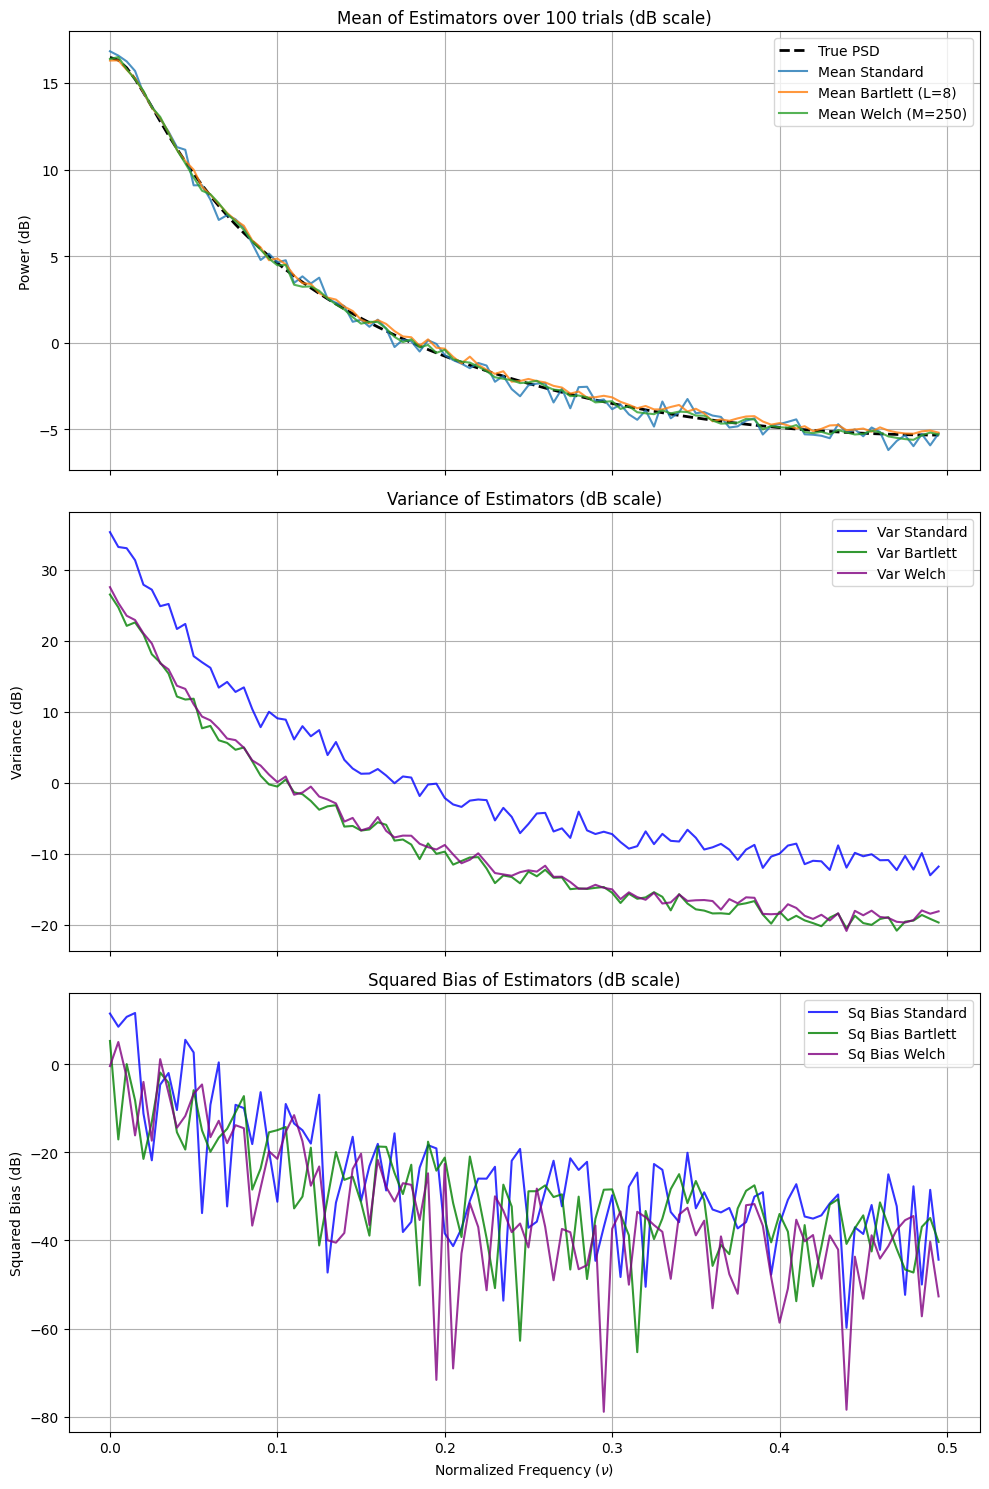

In [111]:
N = 1000
a = 0.85
variance_noise = 1.0
num_trials = 100
nu_values = np.arange(0, 0.5, 0.005)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2

std_estimates = np.zeros((num_trials, len(nu_values)))
bar_estimates = np.zeros((num_trials, len(nu_values)))
wel_estimates = np.zeros((num_trials, len(nu_values)))

np.random.seed(42)

for k in range(num_trials):
    noise = np.random.normal(0, np.sqrt(variance_noise), N)
    signal = np.zeros(N)
    for t in range(1, N):
        signal[t] = a * signal[t-1] + noise[t]
        
    std_func = periodogram(signal, 'standard')
    bar_func = periodogram(signal, 'bartlett', bartlett_L=8)
    wel_func = periodogram(signal, 'welch')
    
    std_estimates[k, :] = [std_func(nu) for nu in nu_values]
    bar_estimates[k, :] = [bar_func(nu) for nu in nu_values]
    wel_estimates[k, :] = [wel_func(nu) for nu in nu_values]

mean_std = np.mean(std_estimates, axis=0)
mean_bar = np.mean(bar_estimates, axis=0)
mean_wel = np.mean(wel_estimates, axis=0)

var_std = np.var(std_estimates, axis=0)
var_bar = np.var(bar_estimates, axis=0)
var_wel = np.var(wel_estimates, axis=0)

sq_bias_std = (mean_std - theoretical_psd)**2
sq_bias_bar = (mean_bar - theoretical_psd)**2
sq_bias_wel = (mean_wel - theoretical_psd)**2

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

axs[0].plot(nu_values, 10*np.log10(theoretical_psd), 'k--', label='True PSD', linewidth=2)
axs[0].plot(nu_values, 10*np.log10(mean_std), label='Mean Standard', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_bar), label='Mean Bartlett (L=8)', alpha=0.8)
axs[0].plot(nu_values, 10*np.log10(mean_wel), label='Mean Welch (M=250)', alpha=0.8)
axs[0].set_title('Mean of Estimators over 100 trials (dB scale)')
axs[0].set_ylabel('Power (dB)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(nu_values, 10*np.log10(var_std), label='Var Standard', color='blue', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_bar), label='Var Bartlett', color='green', alpha=0.8)
axs[1].plot(nu_values, 10*np.log10(var_wel), label='Var Welch', color='purple', alpha=0.8)
axs[1].set_title('Variance of Estimators (dB scale)')
axs[1].set_ylabel('Variance (dB)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(nu_values, 10*np.log10(sq_bias_std + 1e-12), label='Sq Bias Standard', color='blue', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_bar + 1e-12), label='Sq Bias Bartlett', color='green', alpha=0.8)
axs[2].plot(nu_values, 10*np.log10(sq_bias_wel + 1e-12), label='Sq Bias Welch', color='purple', alpha=0.8)
axs[2].set_title('Squared Bias of Estimators (dB scale)')
axs[2].set_xlabel('Normalized Frequency ($\\nu$)')
axs[2].set_ylabel('Squared Bias (dB)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

### 1.3 Parametric estimation : linear prediction

5. Estimate the AR model using either the code you wrote in the previous practical work of 4AI02, or the function lpc (linear prediction method) from Matlab or from the librosa Python package

True AR parameter (a): 0.85
Estimated AR parameter (a_hat): 0.8490
True Noise Variance: 1.0
Estimated Noise Variance: 0.9577


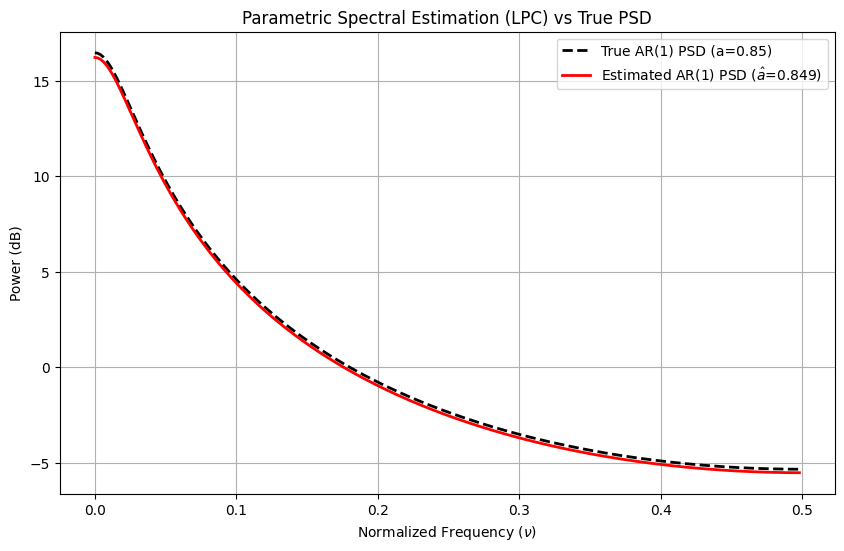

In [115]:
N = 1000
np.random.seed(42)
variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)

# True parameter
a_true = 0.85 

for t in range(1, N):
    signal[t] = a_true * signal[t-1] + noise[t]

lpc_coeffs = librosa.lpc(signal, order=1)

a_hat = -lpc_coeffs[1]

residual = scipy.signal.lfilter(lpc_coeffs, [1], signal)
variance_noise_hat = np.var(residual)

print(f"True AR parameter (a): {a_true}")
print(f"Estimated AR parameter (a_hat): {a_hat:.4f}")
print(f"True Noise Variance: {variance_noise}")
print(f"Estimated Noise Variance: {variance_noise_hat:.4f}")

nu_values = np.arange(0, 0.5, 0.002)

theoretical_psd = variance_noise / np.abs(1 - a_true * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

estimated_psd = variance_noise_hat / np.abs(1 - a_hat * np.exp(-2j * np.pi * nu_values))**2
estimated_psd_db = 10 * np.log10(estimated_psd)


plt.figure(figsize=(10, 6))
plt.plot(nu_values, theoretical_psd_db, 'k--', label=f'True AR(1) PSD (a={a_true})', linewidth=2)
plt.plot(nu_values, estimated_psd_db, 'r-', label=f'Estimated AR(1) PSD ($\\hat{{a}}$={a_hat:.3f})', linewidth=2)

plt.title('Parametric Spectral Estimation (LPC) vs True PSD')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.show()

6. Superimpose the spectral envelope of the estimated AR model with that of the exact AR model and with the periodogram. Comment.

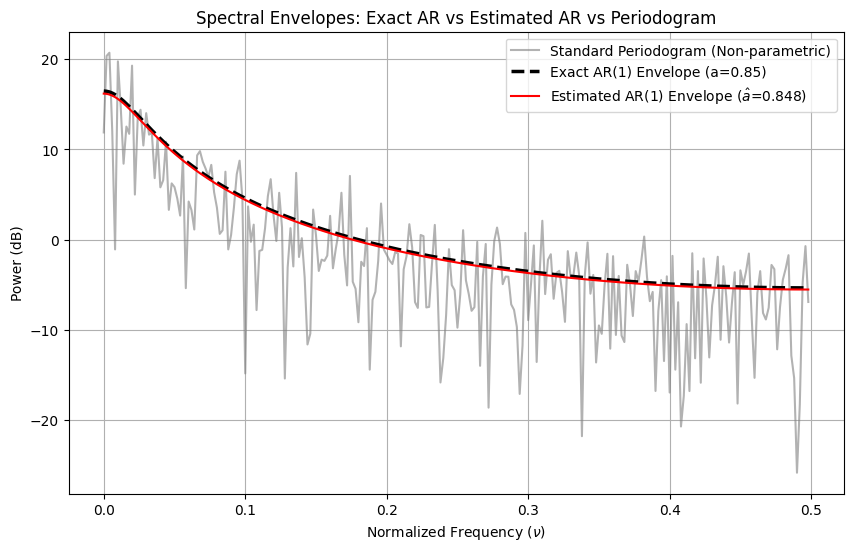

In [118]:
N = 1000
np.random.seed(42)
variance_noise = 1.0
noise = np.random.normal(0, np.sqrt(variance_noise), N)
signal = np.zeros(N)
a = 0.85 
for t in range(1, N):
    signal[t] = a * signal[t-1] + noise[t]

def standard_periodogram(nu):
    return 1/N * np.abs(np.sum(signal * np.exp(-2j * np.pi * nu * np.arange(N))))**2

nu_values = np.arange(0, 0.5, 0.002)
p_std = np.array([standard_periodogram(nu) for nu in nu_values])
p_std_db = 10 * np.log10(p_std)

theoretical_psd = variance_noise / np.abs(1 - a * np.exp(-2j * np.pi * nu_values))**2
theoretical_psd_db = 10 * np.log10(theoretical_psd)

r = sm.tsa.acf(signal, nlags=1)
a_hat = r[1]
var_signal = np.var(signal)
variance_noise_hat = var_signal * (1 - a_hat**2)

estimated_psd = variance_noise_hat / np.abs(1 - a_hat * np.exp(-2j * np.pi * nu_values))**2
estimated_psd_db = 10 * np.log10(estimated_psd)

plt.figure(figsize=(10, 6))
plt.plot(nu_values, p_std_db, color='gray', alpha=0.6, label='Standard Periodogram (Non-parametric)')
plt.plot(nu_values, theoretical_psd_db, 'k--', linewidth=2.5, label=f'Exact AR(1) Envelope (a={a})')
plt.plot(nu_values, estimated_psd_db, 'r-', linewidth=1.5, label=f'Estimated AR(1) Envelope ($\\hat{{a}}$={a_hat:.3f})')

plt.title('Spectral Envelopes: Exact AR vs Estimated AR vs Periodogram')
plt.xlabel('Normalized Frequency ($\\nu$)')
plt.ylabel('Power (dB)')
plt.legend()
plt.grid(True)
plt.show()

**Answer :**

Unlike the highly noisy non-parametric periodogram, the parametric AR model accurately and smoothly captures the true spectral envelope by leveraging the underlying structure of the signal.

### 1.4 Application to speech signals

7. Apply the above methods to a vowel sound (such as ’a’ for example, that we can extract from file aeiou.wav, downloadable from the IP Paris Moodle of 4AI03), and superimpose the estimated spectra. Comment.

## 2. Sum of noisy sinusoids

### 2.1 Synthesis


1. Code a function that synthesizes a signal of length N, consisting of the sum of K real sinusoids defined by their frequencies, amplitudes and origin phases, and a Gaussian white noise of variance $\sigma^2$

### 2.2 Non parametric estimation : periodogram

2. Display the periodograms obtained with the standard method and the Bartlett and Welsh methods,
in the case of K = 2 sinusoidal frequencies $\nu _1$ and $\nu _2$, zero origin phase and same amplitude
equal to 1. We will superimpose in each case the periodogram with two vertical lines centered at
frequencies $\nu _1$ and $\nu _2$, and a horizontal line centered at the variance $\sigma^2$


3. Compare the resolution of the various periodograms, by varying the difference $\Delta \nu = |\nu _1 − \nu _2|$
between both frequencies, as well as the signal-to-noise ratio (SNR) in dB.

### 2.3 Parametric estimation : linear prediction

4. Estimate a fourth order AR model using the linear prediction method.

5. Superimpose the estimated AR model with the previous figures, always by varying the gap $\Delta \nu$, as
well as the SNR in dB. Comment on the results in terms of resolution.

### 2.4 Parametric estimation : Capon estimator

6. Code a function that implements the Capon estimator

7. Compare the resolution of this method with the two previous methods, always by varying $\Delta \nu$, as
well as the SNR in dB.


## 3. Autoregressive-moving-average process

### 3.1 Synthesis

1. Code a function that synthesizes an autoregressive-moving-average (ARMA) process of length N,
defined by its AR and MA coefficients and by the innovation variance $\sigma^2$

### 3.2 Non-parametric estimation : periodogram

2. Display the periodograms obtained with the different methods, in the case of an ARMA process
of order (1, 1) whose parameters can be chosen by hand. We will superimpose in each case the
periodogram with the known PSD of the ARMA process.

3. Compare these different estimators in terms of bias and variance.

### 3.3 Parametric estimation : Durbin method

4. Code a function that implements the Durbin method (estimation of the AR part by shifting the
autocorrelation, estimation of the MA part via a long AR)

5. Superimpose the spectral envelope of the estimated ARMA model with that of the exact ARMA
model and with the periodogram. Comment.

### 3.4 Application to speech signals

6. Apply the above methods to a nasal vowel sound (such as ’in’ for example, that we will be able to
extract from file an_in_on.wav, downloadable on the IP Paris Moodle of 4AI03), and superimpose the estimated spectra.